In [1]:
import io
import os
import time
import json
import pickle
from pathlib import Path
from math import log, sqrt
from functools import partial
import string

import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from sklearn.decomposition import NMF, PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.patheffects as patheffects



In [2]:
with h5py.File('data/NMC_LGPS_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf = Xf.clip(min=0, max=1e32)

print(x_real, y_real, x_reci, y_reci)

36 63 187 187


In [3]:
def add_cbar(fig1, ax1, im1, ticks=None):
    divider = make_axes_locatable(ax1)
    cax1 = divider.append_axes('right', size='5%', pad=0.05)
    clb = fig1.colorbar(im1, cax=cax1, orientation='vertical')

    if ticks is not None:
        clb.set_ticks(ticks)
        def format_scientific(x):
            if x == 0: return '0'
            sign = '-' if x < 0 else ''
            # Get exponent
            import math
            exponent = int(math.floor(math.log10(abs(x))))
            return f'{sign}$10^{{{exponent}}}$'
            
        labels = [format_scientific(t) for t in ticks]
        clb.set_ticklabels(labels)

In [4]:
# PCA
n_components = 50
pca = PCA(n_components = n_components)
W = pca.fit_transform(Xf)
H = pca.components_

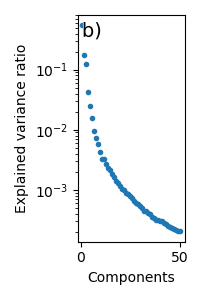

In [5]:
# check linearity and components

plt.figure(figsize=(2,3))
plt.plot(np.arange(n_components) + 1, pca.explained_variance_ratio_, '.')
plt.ylabel('Explained variance ratio')
plt.xlabel('Components')
plt.yscale('log')
# plt.ylim([1e-3, 1])
plt.tight_layout()
plt.gca().text(0.04, 0.97, 'b)', transform=plt.gca().transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
plt.savefig('figures/NMC_LGPS_EVR.png', dpi=300)

LOSS:  220059.8472686811


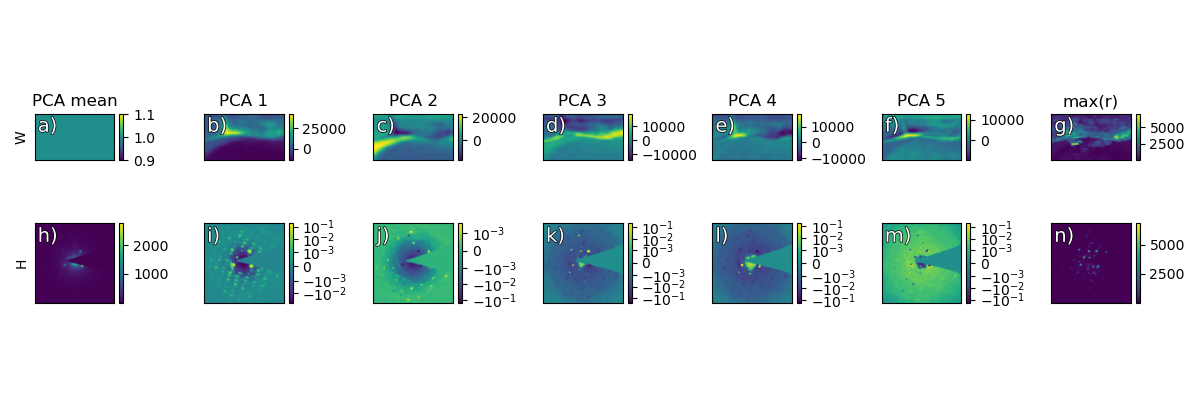

In [6]:
# pca with 5 components.
k_PCA = 5
pca = PCA(n_components = k_PCA)
W_PCA = pca.fit_transform(Xf)
H_PCA = pca.components_

# calculate residuals
r_PCA = np.abs(Xf - pca.mean_ - np.dot(W_PCA, H_PCA))

res_comp_PCA = np.max(r_PCA, axis=0).reshape((x_reci, y_reci))
res_map_PCA = np.max(r_PCA, axis=1).reshape((x_real, y_real))

loss_PCA = np.sqrt(np.dot(r_PCA.ravel(), r_PCA.ravel()))
print("LOSS: ", loss_PCA)

# make graph
fig, axs = plt.subplots(nrows=2, ncols=k_PCA + 2, figsize=(12, 4))

im = axs[0, 0].imshow(np.ones((X.shape[0], X.shape[1])))
add_cbar(fig, axs[0, 0], im)

im = axs[1, 0].imshow(pca.mean_.reshape(X.shape[2], X.shape[3]))
add_cbar(fig, axs[1, 0], im)

im = axs[0, k_PCA+1].imshow(res_map_PCA)
add_cbar(fig, axs[0, k_PCA+1], im)

im = axs[1, k_PCA+1].imshow(res_comp_PCA)
add_cbar(fig, axs[1, k_PCA+1], im)

for i in range(k_PCA):
    im = axs[0, i + 1].imshow(W_PCA[:, i].reshape(X.shape[0], X.shape[1]))
    add_cbar(fig, axs[0, i+1], im)
    im = axs[1, i + 1].imshow(H_PCA[i, :].reshape(X.shape[2], X.shape[3]), norm=SymLogNorm(linthresh=1e-3))
    add_cbar(fig, axs[1, i+1], im)


labels = ['PCA mean'] + [f'PCA {i+1}' for i in range(k_PCA)] + ['max(r)']
for i in range(k_PCA+2):
    axs[0, i].set_title(labels[i])
plt.tight_layout()

axs[0, 0].set_ylabel('W')
axs[1, 0].set_ylabel('H')

letters = list(string.ascii_lowercase)
for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])
        
plt.tight_layout()
plt.savefig('figures/NMC_LGPS_PCA.png', dpi=300)

In [7]:
import time
from math import log, sqrt
from functools import partial

from sklearn.utils import check_random_state
from sklearn.decomposition._nmf import _initialize_nmf, _beta_divergence
from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast

from scipy import fftpack, linalg, sparse
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import safe_sparse_dot

def random_axis_sample(A, l, axis, random_state):
    return random_state.choice(A.shape[axis], size=l, replace=False)

def random_gaussian_map(A, l, axis, random_state):
    return random_state.standard_normal(size=(A.shape[axis], l)).astype(A.dtype)

def random_uniform_map(A, l, axis, random_state):
    return random_state.uniform(-1, 1, size=(A.shape[axis], l)).astype(A.dtype)

def sparse_random_map(A, l, axis, density, random_state):
    values = (-sqrt(1. / density), sqrt(1. / density))
    data_rvs = partial(random_state.choice, values)
    return sparse.random(A.shape[axis], l, density=density, data_rvs=data_rvs,
                         random_state=random_state, dtype=A.dtype)

def johnson_lindenstrauss(A, l, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    Omega = random_gaussian_map(A, l, axis, random_state)
    if axis == 0:
        return Omega.T.dot(A)
    return A.dot(Omega)

def sparse_johnson_lindenstrauss(A, l, density=None, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    if density is None:
        density = log(A.shape[0]) / A.shape[0]
    Omega = sparse_random_map(A, l, axis, density, random_state)
    if axis == 0:
        return safe_sparse_dot(Omega.T, A)
    return safe_sparse_dot(A, Omega)

def orthonormalize(A, overwrite_a=True, check_finite=False):
    Q, _ = linalg.qr(A, overwrite_a=overwrite_a, check_finite=check_finite,
                     mode='economic', pivoting=False)
    return Q

def perform_subspace_iterations(A, Q, n_iter=2, axis=1):
    if axis == 0:
        Q = Q.T
    Q = orthonormalize(Q)
    for _ in range(n_iter):
        if axis == 0:
            Z = orthonormalize(A.dot(Q))
            Q = orthonormalize(A.T.dot(Z))
        else:
            Z = orthonormalize(A.T.dot(Q))
            Q = orthonormalize(A.dot(Z))
    if axis == 0:
        return Q.T
    return Q

def conjugate_transpose(A):
    if A.dtype == np.complexfloating:
        return A.conj().T
    return A.T

def _compute_rqb(A, rank, oversample, n_subspace, sparse, random_state):
    if sparse:
        Q = sparse_johnson_lindenstrauss(A, rank + oversample,
                                         random_state=random_state)
    else:
        Q = johnson_lindenstrauss(A, rank + oversample, random_state=random_state)
    if n_subspace > 0:
        Q = perform_subspace_iterations(A, Q, n_iter=n_subspace, axis=1)
    else:
        Q = orthonormalize(Q)
    B = conjugate_transpose(Q).dot(A)
    return Q, B

def compute_rqb(A, rank, oversample=20, n_subspace=2, n_blocks=1, sparse=False,
                random_state=None):
    if n_blocks > 1:
        m, n = A.shape
        row_sets = np.array_split(range(m), n_blocks)
        Q_block = []
        K = []
        for rows in row_sets:
            Qtemp, Ktemp = _compute_rqb(np.asarray_chkfinite(A[rows, :]), 
                rank=rank, oversample=oversample, n_subspace=n_subspace, 
                sparse=sparse, random_state=random_state)
            Q_block.append(Qtemp)
            K.append(Ktemp)
        Q_small, B = _compute_rqb(
            np.concatenate(K, axis=0), rank=rank, oversample=oversample,
            n_subspace=n_subspace, sparse=sparse, random_state=random_state)
        Q_small = np.vsplit(Q_small, n_blocks)
        Q = [Q_block[i].dot(Q_small[i]) for i in range(n_blocks)]
        Q = np.concatenate(Q, axis=0)
    else:
        Q, B = _compute_rqb(np.asarray_chkfinite(A), 
            rank=rank, oversample=oversample, n_subspace=n_subspace,
            sparse=sparse, random_state=random_state)
    return Q, B

def nmf(X, rank, init='nndsvd', maxiter=200, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 random_state=None):
    random_state = check_random_state(random_state)
    X = np.asarray_chkfinite(X)
    X = check_array(X, accept_sparse="csr")
    m, n = X.shape
    flipped = False
    if n > m:
        X = X.T
        m, n = X.shape
        flipped = True
    if np.any(X < 0):
        raise ValueError("Input matrix with nonnegative elements is required.")
        
    W, H = _initialize_nmf(X, rank, init=init, eps=1e-6, random_state=random_state)
    Ht = np.array(H.T, order='C')

    if QB_project:
        Q, B = compute_rqb(X, rank, oversample=oversample,
                        n_subspace=n_subspace, random_state=random_state)
        W_tilde = Q.T.dot(W)
    
    if calculate_loss:
        losses = []
        tols = []

    violation = 0.0
    for niter in range(maxiter):
        if QB_project:
            WtW = W.T.dot(W)
            BtW = B.T.dot(W_tilde)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, BtW, permutation.astype(np.intp))
            
            HHt = Ht.T.dot(Ht)
            BHt = Q.dot(B.dot(Ht))
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, BHt, permutation.astype(np.intp))

            W_tilde = Q.T.dot(W)
        else:
            WtW = W.T.dot(W)
            XtW = X.T.dot(W)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, XtW, permutation.astype(np.intp))

            HHt = np.dot(Ht.T, Ht)
            XHt = safe_sparse_dot(X, Ht)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, XHt, permutation.astype(np.intp))

        if niter == 0:
            if violation == 0: break
            violation_init = violation

        if calculate_loss:
            if flipped:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            else:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            losses.append(loss)
            tols.append(violation / violation_init)

    if calculate_loss:
        if flipped:
            return(Ht, W.T, np.array(losses), np.array(tols))
        return(W, Ht.T, np.array(losses), np.array(tols))
    if flipped:
        return(Ht, W.T)
    return(W, Ht.T)

In [8]:
# calculate relevant losses and tolerances.
k_NMF = 5

if os.path.exists('factorizations/NMC_LGPS_nmf_R.pkl'):
    with open('factorizations/NMC_LGPS_nmf_R.pkl', 'rb') as f:
        W_R, H_R, loss_R, tols_R = pickle.load(f)
else:
    start = time.time()
    W_R, H_R, loss_R, tols_R = nmf(Xf, k_NMF, init='random', maxiter=1000, calculate_loss=True, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    if not os.path.exists('factorizations'): os.makedirs('factorizations')
    with open('factorizations/NMC_LGPS_nmf_R.pkl', 'wb') as f:
        pickle.dump((W_R, H_R, loss_R, tols_R), f)

if os.path.exists('factorizations/NMC_LGPS_nmf_RQ.pkl'):
    with open('factorizations/NMC_LGPS_nmf_RQ.pkl', 'rb') as f:
        W_RQ, H_RQ, loss_RQ, tols_RQ = pickle.load(f)
else:
    start = time.time()
    W_RQ, H_RQ, loss_RQ, tols_RQ = nmf(Xf, k_NMF, init='random', maxiter=1000, calculate_loss=True, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/NMC_LGPS_nmf_RQ.pkl', 'wb') as f:
        pickle.dump((W_RQ, H_RQ, loss_RQ, tols_RQ), f)

if os.path.exists('factorizations/NMC_LGPS_nmf_N.pkl'):
    with open('factorizations/NMC_LGPS_nmf_N.pkl', 'rb') as f:
        W_N, H_N, loss_N, tols_N = pickle.load(f)
else:
    start = time.time()
    W_N, H_N, loss_N, tols_N = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=True, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/NMC_LGPS_nmf_N.pkl', 'wb') as f:
        pickle.dump((W_N, H_N, loss_N, tols_N), f)

if os.path.exists('factorizations/NMC_LGPS_nmf_NQ.pkl'):
    with open('factorizations/NMC_LGPS_nmf_NQ.pkl', 'rb') as f:
        W_NQ, H_NQ, loss_NQ, tols_NQ = pickle.load(f)
else:
    start = time.time()
    W_NQ, H_NQ, loss_NQ, tols_NQ = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=True, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/NMC_LGPS_nmf_NQ.pkl', 'wb') as f:
        pickle.dump((W_NQ, H_NQ, loss_NQ, tols_NQ), f)

# these times are so long because the explicit loss calculation.
# 656.1221601963043
# 569.1798136234283
# 706.5264167785645
# 579.5178253650665

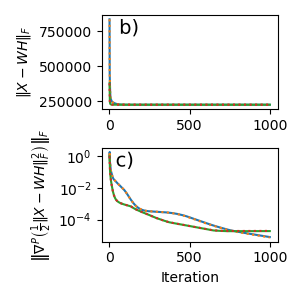

In [9]:
ix = np.arange(loss_R.size) + 1

fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(3,3))
axs[0].plot(ix, loss_R)
axs[0].plot(ix, loss_RQ, ':', ms=0.5)
axs[0].plot(ix, loss_N)
axs[0].plot(ix, loss_NQ, ':', ms=0.5)
axs[0].set_ylabel(r'$\|X-WH\|_F$')
axs[1].plot(ix, tols_R)
axs[1].plot(ix, tols_RQ, ':', ms=0.5)
axs[1].plot(ix, tols_N)
axs[1].plot(ix, tols_NQ, ':', ms=0.5)
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\left\| \nabla^P \left( \frac{1}{2} \|X - WH\|_F^2 \right) \right\|_F$')

axs[0].text(0.1, 0.96, 'b)', transform=axs[0].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
axs[1].text(0.08, 0.96, 'c)', transform=axs[1].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

plt.tight_layout()
if not os.path.exists('figures'): os.makedirs('figures')
plt.savefig("figures/NMC_LGPS_evolution.png", dpi=300)

In [10]:
if os.path.exists('factorizations/NMC_LGPS_nmf_N2.pkl'):
    with open('factorizations/NMC_LGPS_nmf_N2.pkl', 'rb') as f:
        W_N2, H_N2 = pickle.load(f)
else:
    start = time.time()
    W_N2, H_N2 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=False, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/NMC_LGPS_nmf_N2.pkl', 'wb') as f:
        pickle.dump((W_N2, H_N2), f)

scale = H_N2.max(axis=1)
H_N2 /= scale[:, np.newaxis]
W_N2 *= scale

WH_N2 = np.dot(W_N2, H_N2)
r_N2 = np.abs(Xf - WH_N2)

res_comp_N2 = np.max(r_N2, axis=0).reshape((x_reci, y_reci))
res_map_N2 = np.max(r_N2, axis=1).reshape((x_real, y_real))

# 118.1340401172638

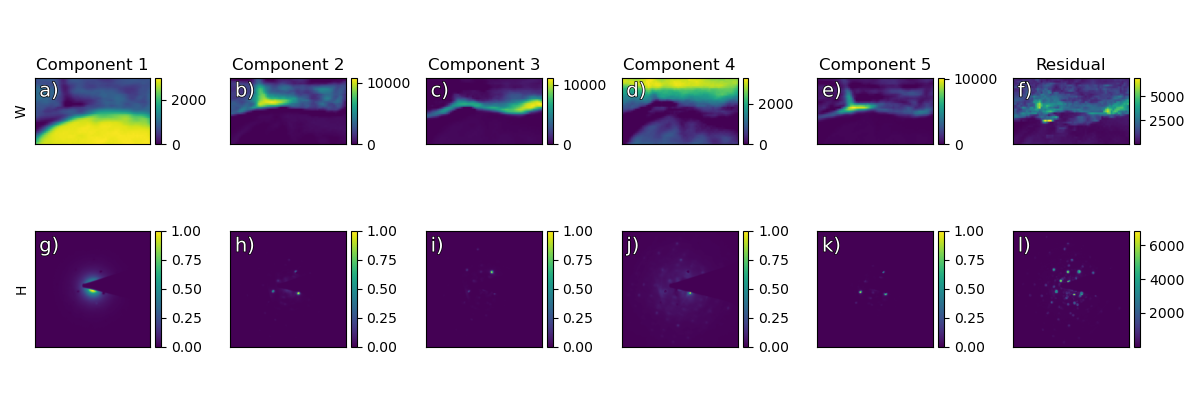

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=k_NMF + 1, figsize=(12, 4), sharex='row', sharey='row')
for i in range(k_NMF):
    im = axs[0, i].imshow(W_N2[:, i].reshape(x_real, y_real))
    add_cbar(fig, axs[0, i], im)
    im = axs[1, i].imshow(H_N2[i, :].reshape(x_reci, y_reci))
    add_cbar(fig, axs[1, i], im)

im = axs[0, k_NMF].imshow(res_map_N2)
add_cbar(fig, axs[0, k_NMF], im)
im = axs[1, k_NMF].imshow(res_comp_N2)
add_cbar(fig, axs[1, k_NMF], im)

for i in range(k_NMF):
    axs[0, i].set_title(f'Component {i+1}')
axs[0, k_NMF].set_title('Residual')

axs[0, 0].set_ylabel('W')
axs[1, 0].set_ylabel('H')

for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/NMC_LGPS_noQB.png", dpi=300)

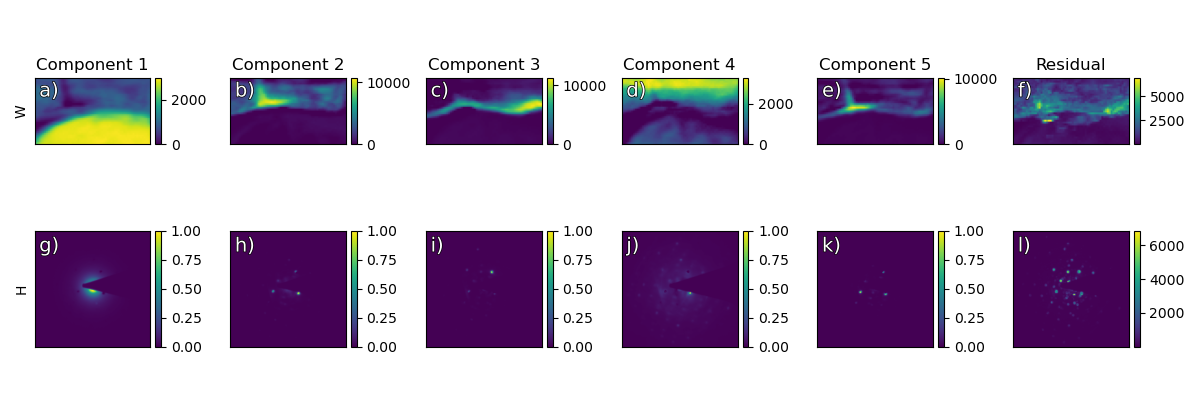

In [12]:
if os.path.exists('factorizations/NMC_LGPS_nmf_NQ2.pkl'):
    with open('factorizations/NMC_LGPS_nmf_NQ2.pkl', 'rb') as f:
        W_NQ2, H_NQ2 = pickle.load(f)
else:
    start = time.time()
    W_NQ2, H_NQ2 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/NMC_LGPS_nmf_NQ2.pkl', 'wb') as f:
        pickle.dump((W_NQ2, H_NQ2), f)

scale = H_NQ2.max(axis=1)
H_NQ2 /= scale[:, np.newaxis]
W_NQ2 *= scale

WH_NQ2 = np.dot(W_NQ2, H_NQ2)
r_NQ2 = np.abs(Xf - WH_NQ2)

res_comp_NQ2 = np.max(r_NQ2, axis=0).reshape((x_reci, y_reci))
res_map_NQ2 = np.max(r_NQ2, axis=1).reshape((x_real, y_real))

fig, axs = plt.subplots(nrows=2, ncols=k_NMF + 1, figsize=(12, 4))
for i in range(k_NMF):
    im = axs[0, i].imshow(W_NQ2[:, i].reshape(x_real, y_real))
    add_cbar(fig, axs[0, i], im)
    im = axs[1, i].imshow(H_NQ2[i, :].reshape(x_reci, y_reci)) 
    add_cbar(fig, axs[1, i], im)

im = axs[0, k_NMF].imshow(res_map_NQ2)
add_cbar(fig, axs[0, k_NMF], im)
im = axs[1, k_NMF].imshow(res_comp_NQ2) 
add_cbar(fig, axs[1, k_NMF], im)

for i in range(k_NMF):
    axs[0, i].set_title(f'Component {i+1}')
axs[0, k_NMF].set_title('Residual')

axs[0, 0].set_ylabel('W')
axs[1, 0].set_ylabel('H')

for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/NMC_LGPS_QB.png", dpi=300)

# 4.615447282791138

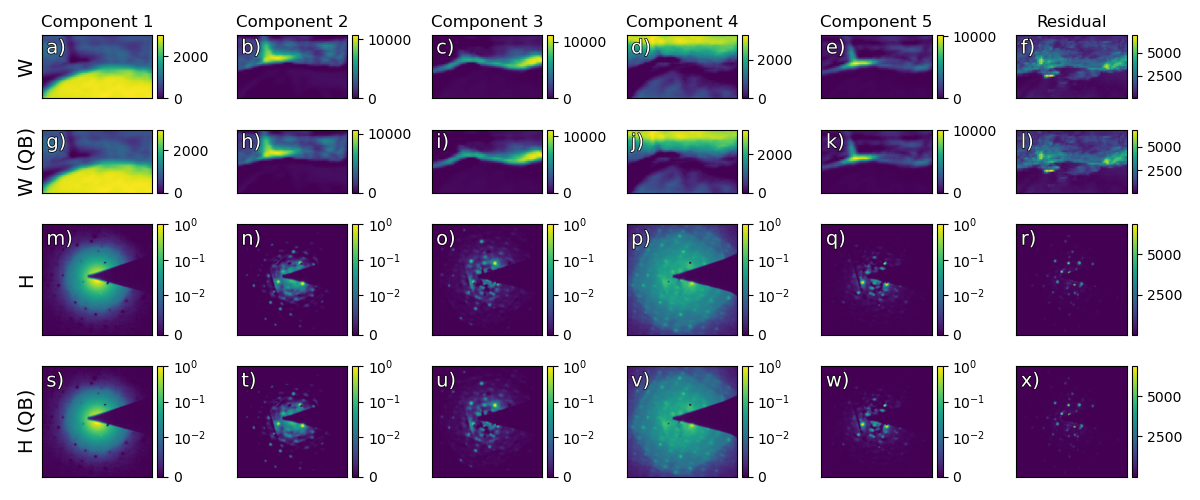

In [13]:
hr_W = x_real / y_real
hr_H = x_reci / y_reci
fig, axs = plt.subplots(nrows=4, ncols=k_NMF + 1, figsize=(12, 5), gridspec_kw={'height_ratios': [hr_W, hr_W, hr_H, hr_H]})

# Row 0: W noQB
for i in range(k_NMF):
    im = axs[0, i].imshow(W_N2[:, i].reshape(x_real, y_real))
    add_cbar(fig, axs[0, i], im)
im = axs[0, k_NMF].imshow(res_map_N2)
add_cbar(fig, axs[0, k_NMF], im)

# Row 1: W QB
for i in range(k_NMF):
    im = axs[1, i].imshow(W_NQ2[:, i].reshape(x_real, y_real))
    add_cbar(fig, axs[1, i], im)
im = axs[1, k_NMF].imshow(res_map_NQ2)
add_cbar(fig, axs[1, k_NMF], im)

# Row 2: H noQB
for i in range(k_NMF):
    im = axs[2, i].imshow(H_N2[i, :].reshape(x_reci, y_reci), norm=SymLogNorm(linthresh=1e-2)) 
    add_cbar(fig, axs[2, i], im)
im = axs[2, k_NMF].imshow(res_comp_N2) 
add_cbar(fig, axs[2, k_NMF], im)

# Row 3: H QB
for i in range(k_NMF):
    im = axs[3, i].imshow(H_NQ2[i, :].reshape(x_reci, y_reci), norm=SymLogNorm(linthresh=1e-2)) 
    add_cbar(fig, axs[3, i], im)
im = axs[3, k_NMF].imshow(res_comp_NQ2) 
add_cbar(fig, axs[3, k_NMF], im)

for i in range(k_NMF):
    axs[0, i].set_title(f'Component {i+1}')
axs[0, k_NMF].set_title('Residual')

font_dict = {'fontsize': 14}
axs[0, 0].set_ylabel('W', fontdict=font_dict)
axs[1, 0].set_ylabel('W (QB)', fontdict=font_dict)
axs[2, 0].set_ylabel('H', fontdict=font_dict)
axs[3, 0].set_ylabel('H (QB)', fontdict=font_dict)

for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/NMC_LGPS_combined.png", dpi=300)

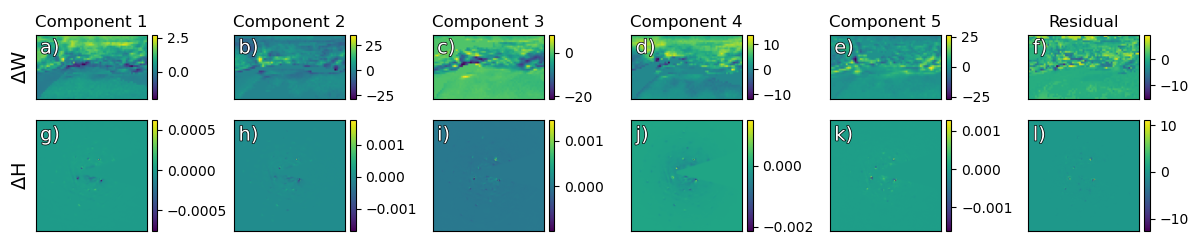

In [14]:
fig2, axs2 = plt.subplots(nrows=2, ncols=k_NMF + 1, figsize=(12, 2.5), gridspec_kw={'height_ratios': [hr_W, hr_H]})

# Row 0: W diff
for i in range(k_NMF):
    im = axs2[0, i].imshow((W_N2[:, i] - W_NQ2[:, i]).reshape(x_real, y_real))
    add_cbar(fig2, axs2[0, i], im)
im = axs2[0, k_NMF].imshow(res_map_N2 - res_map_NQ2)
add_cbar(fig2, axs2[0, k_NMF], im)

# Row 1: H diff
for i in range(k_NMF):
    im = axs2[1, i].imshow((H_N2[i, :] - H_NQ2[i, :]).reshape(x_reci, y_reci)) 
    add_cbar(fig2, axs2[1, i], im)
im = axs2[1, k_NMF].imshow(res_comp_N2 - res_comp_NQ2) 
add_cbar(fig2, axs2[1, k_NMF], im)

for i in range(k_NMF):
    axs2[0, i].set_title(f'Component {i+1}')
axs2[0, k_NMF].set_title('Residual')

font_dict = {'fontsize': 14}
axs2[0, 0].set_ylabel(r'$\Delta$W', fontdict=font_dict)
axs2[1, 0].set_ylabel(r'$\Delta$H', fontdict=font_dict)

for i, ax in enumerate(axs2.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/NMC_LGPS_deltas.png", dpi=300)

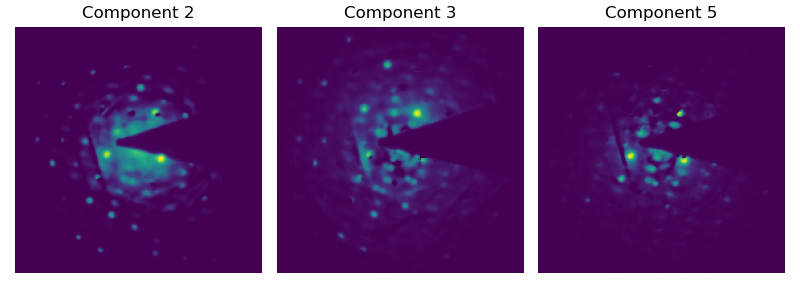

In [23]:

fig, axs = plt.subplots(1, 3, figsize=(8,3), sharex=True, sharey=True)
components = [1, 2, 4] 
for i, c in enumerate(components):
    axs[i].imshow(H_N2[c].reshape(x_reci, y_reci), norm=SymLogNorm(linthresh=1e-2))
    axs[i].set_title(f'Component {c+1}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()